<a href="https://colab.research.google.com/github/emanaak04-svg/sleep-apnea-detection/blob/main/amna/respiratory_feature_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1: Install Libraries and Mount Google Drive
We install required libraries and connect Google Drive
to access the MIT-BIH dataset files for respiratory
feature extraction.

In [2]:
!pip install wfdb -q

from google.colab import drive
drive.mount('/drive')

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, welch
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported")

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
All libraries imported


## 2: Load Respiratory Signal for All 5 Patients
We load each patient file and extract the respiratory
signal from channel 3. This signal measures breathing
effort and airflow during sleep. We use the same 30-second
windowing and labels as ECG and EEG to keep everything aligned.

In [3]:
import shutil

DATA_PATH = "/drive/MyDrive/shhs-data"
patients = ['slp01a', 'slp02a', 'slp03', 'slp04', 'slp14']

all_resp_segments = []
all_labels = []
WINDOW_SIZE = 30

for p in patients:
    # Copy files to local Colab storage
    shutil.copy(f"{DATA_PATH}/{p}.dat", f"/content/{p}.dat")
    shutil.copy(f"{DATA_PATH}/{p}.hea", f"/content/{p}.hea")
    shutil.copy(f"{DATA_PATH}/{p}.st",  f"/content/{p}.st")

    record = wfdb.rdrecord(f"/content/{p}")
    fs = record.fs
    resp = record.p_signal[:, 3]  # Respiratory is channel 3

    ann = wfdb.rdann(f"/content/{p}", 'st')
    samples_per_window = int(WINDOW_SIZE * fs)

    for i, sample in enumerate(ann.sample):
        label_text = ann.aux_note[i].strip()
        label = 1 if 'A' in label_text else 0
        start = sample
        end = start + samples_per_window
        if end <= len(resp):
            segment = resp[start:end]
            all_resp_segments.append(segment)
            all_labels.append(label)

all_labels = np.array(all_labels)
total = len(all_labels)
apnea = np.sum(all_labels == 1)
normal = np.sum(all_labels == 0)

print(f"Respiratory signal loaded")
print(f"Total windows : {total}")
print(f"Normal        : {normal} ({100*normal/total:.1f}%)")
print(f"Apnea         : {apnea} ({100*apnea/total:.1f}%)")

Respiratory signal loaded
Total windows : 2754
Normal        : 2389 (86.7%)
Apnea         : 365 (13.3%)


## 3: Extract Respiratory Features from One Window
We extract 7 features from each 30-second respiratory window:
- Breathing rate: number of breaths per minute
- Mean amplitude: average size of each breath
- Std amplitude: variability in breath size
- Inspiration/Expiration ratio: balance of breathing cycle
- Breath regularity: how consistent the breathing rhythm is
- Mean peak distance: average time between breaths
- Apnea index: proportion of signal near zero (no breathing)
During apnea breathing stops completely so these features
change dramatically compared to normal breathing windows.

In [4]:
def extract_resp_features(resp_window, fs=250):
    # Normalize window
    resp_norm = (resp_window - np.mean(resp_window)) / (np.std(resp_window) + 1e-8)

    # Find breath peaks
    peaks, props = find_peaks(resp_norm, distance=int(1.5*fs), height=0.1)

    # Breathing rate (breaths per minute)
    if len(peaks) >= 2:
        peak_distances = np.diff(peaks) / fs  # in seconds
        mean_peak_dist = np.mean(peak_distances)
        breathing_rate = 60 / mean_peak_dist
        breath_regularity = np.std(peak_distances) / mean_peak_dist
    else:
        mean_peak_dist = 0
        breathing_rate = 0
        breath_regularity = 1

    # Amplitude features
    mean_amplitude = np.mean(np.abs(resp_norm))
    std_amplitude = np.std(resp_norm)

    # Apnea index — proportion of signal near zero
    apnea_index = np.sum(np.abs(resp_norm) < 0.2) / len(resp_norm)

    # Inspiration/Expiration ratio
    positive = np.sum(resp_norm > 0)
    negative = np.sum(resp_norm < 0)
    ie_ratio = positive / (negative + 1e-8)

    return {
        'breathing_rate': breathing_rate,
        'mean_amplitude': mean_amplitude,
        'std_amplitude': std_amplitude,
        'mean_peak_dist': mean_peak_dist,
        'breath_regularity': breath_regularity,
        'apnea_index': apnea_index,
        'ie_ratio': ie_ratio
    }

# Test on first window
features = extract_resp_features(all_resp_segments[0], fs=250)
print("Respiratory features extracted from first window!")
print(f"\nSample features:")
for key, val in features.items():
    print(f"  {key:20s}: {val:.4f}")

Respiratory features extracted from first window!

Sample features:
  breathing_rate      : 24.9546
  mean_amplitude      : 0.8827
  std_amplitude       : 1.0000
  mean_peak_dist      : 2.4044
  breath_regularity   : 0.4022
  apnea_index         : 0.0593
  ie_ratio            : 1.5970


## 4: Extract Respiratory Features for All 2754 Windows
We apply the feature extraction function to every single
respiratory window. This gives us 7 features per window
describing the breathing pattern during that 30-second period.

In [5]:
all_features = []
valid_labels = []
skipped = 0

for i in range(len(all_resp_segments)):
    features = extract_resp_features(all_resp_segments[i], fs=250)
    if features is not None:
        all_features.append(features)
        valid_labels.append(all_labels[i])
    else:
        skipped += 1

df_features = pd.DataFrame(all_features)
df_features['label'] = valid_labels

print(f"Feature extraction complete!")
print(f"Total windows    : {len(all_resp_segments)}")
print(f"Valid windows    : {len(df_features)}")
print(f"Skipped windows  : {skipped}")
print(f"\nFeature table shape: {df_features.shape}")
print(f"\nFirst 5 rows:")
print(df_features.head())

Feature extraction complete!
Total windows    : 2754
Valid windows    : 2754
Skipped windows  : 0

Feature table shape: (2754, 8)

First 5 rows:
   breathing_rate  mean_amplitude  std_amplitude  mean_peak_dist  \
0       24.954628        0.882696            1.0        2.404364   
1       24.416712        0.889593            1.0        2.457333   
2       22.996516        0.888448            1.0        2.609091   
3       22.348639        0.871396            1.0        2.684727   
4       24.466494        0.873521            1.0        2.452333   

   breath_regularity  apnea_index  ie_ratio  label  
0           0.402230     0.059333  1.596953      1  
1           0.362695     0.063600  1.508361      1  
2           0.373261     0.066533  1.499167      1  
3           0.409386     0.069867  1.510880      0  
4           0.387018     0.065733  1.616888      0  


## 5: Visualize Respiratory Features — Apnea vs Normal
We plot the distribution of each respiratory feature
comparing apnea windows vs normal windows.
Respiratory features should show the clearest differences
since breathing directly stops during apnea events.

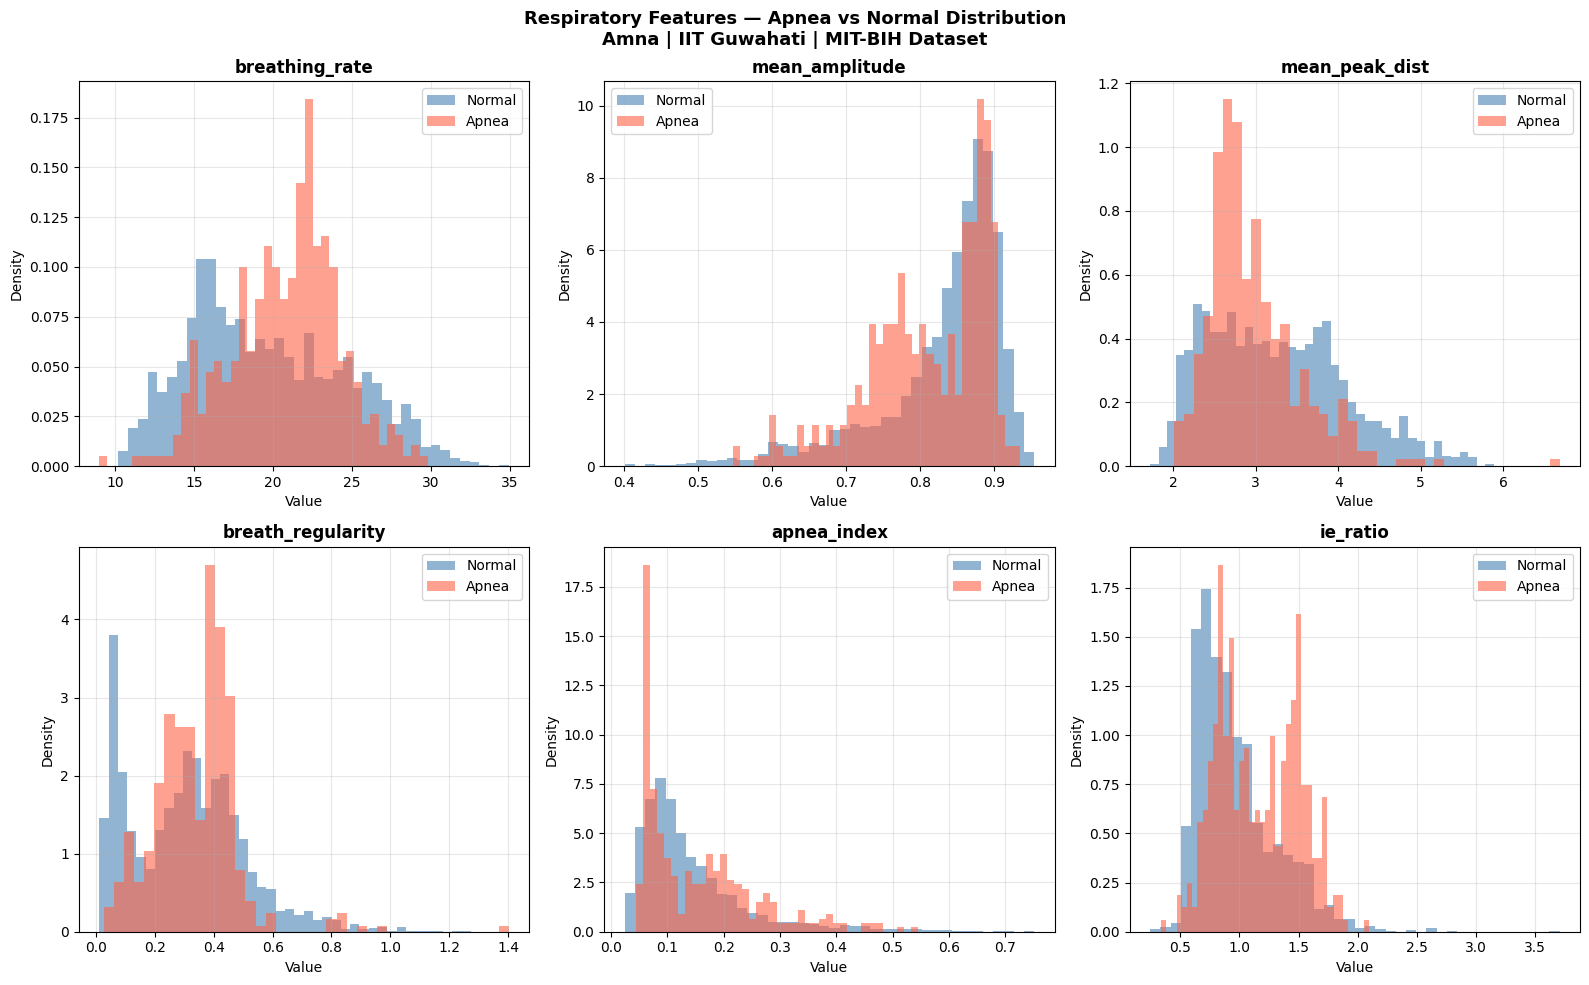

Plot saved


In [6]:
features_to_plot = ['breathing_rate', 'mean_amplitude', 'mean_peak_dist',
                    'breath_regularity', 'apnea_index', 'ie_ratio']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Respiratory Features — Apnea vs Normal Distribution\nAmna | IIT Guwahati | MIT-BIH Dataset",
             fontsize=13, fontweight='bold')

normal_df = df_features[df_features['label'] == 0]
apnea_df  = df_features[df_features['label'] == 1]

for idx, feat in enumerate(features_to_plot):
    ax = axes[idx // 3][idx % 3]
    ax.hist(normal_df[feat], bins=40, alpha=0.6, color='steelblue', label='Normal', density=True)
    ax.hist(apnea_df[feat],  bins=40, alpha=0.6, color='tomato',    label='Apnea',  density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/drive/MyDrive/shhs-data/resp_features_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

## 6: Save the Respiratory Feature Table
We save the complete respiratory feature table as a CSV file.
On Day 5 this will be merged with ECG HRV features and EEG
band power features into one final table for model training.

In [7]:
df_features.to_csv("/drive/MyDrive/shhs-data/resp_features.csv", index=False)

print(f"Features saved")
print(f"File: resp_features.csv")
print(f"Shape: {df_features.shape}")
print(f"\nColumns: {list(df_features.columns)}")

Features saved
File: resp_features.csv
Shape: (2754, 8)

Columns: ['breathing_rate', 'mean_amplitude', 'std_amplitude', 'mean_peak_dist', 'breath_regularity', 'apnea_index', 'ie_ratio', 'label']
